# Gráfico desde Resultados.xlsx

Este notebook carga `Resultados.xlsx` y genera una imagen lo m?s parecida posible al ejemplo `Ejemplo.png`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import textwrap
from matplotlib.patches import Patch
from matplotlib import font_manager as fm

# Asegura soporte de acentos
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']


In [2]:
# Cargar resultados
# El archivo tiene una columna 'Posicion' y luego una columna por equipo
resultados = pd.read_excel('Resultados.xlsx')

# Usar 'Posicion' como ?ndice
resultados = resultados.set_index('Posicion')

# Tomar solo posiciones 1..8
resultados_top8 = resultados.loc[resultados.index <= 8].copy()

# Ordenar posiciones ascendente (1 abajo, 8 arriba en la barra apilada)
resultados_top8 = resultados_top8.sort_index()

# Transponer para graficar por equipo
plot_df = resultados_top8.T


C:\Users\Acer\AppData\Local\Temp\ipykernel_15180\4123185087.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cell_text = table_df.applymap(lambda v: f'{v}%').values


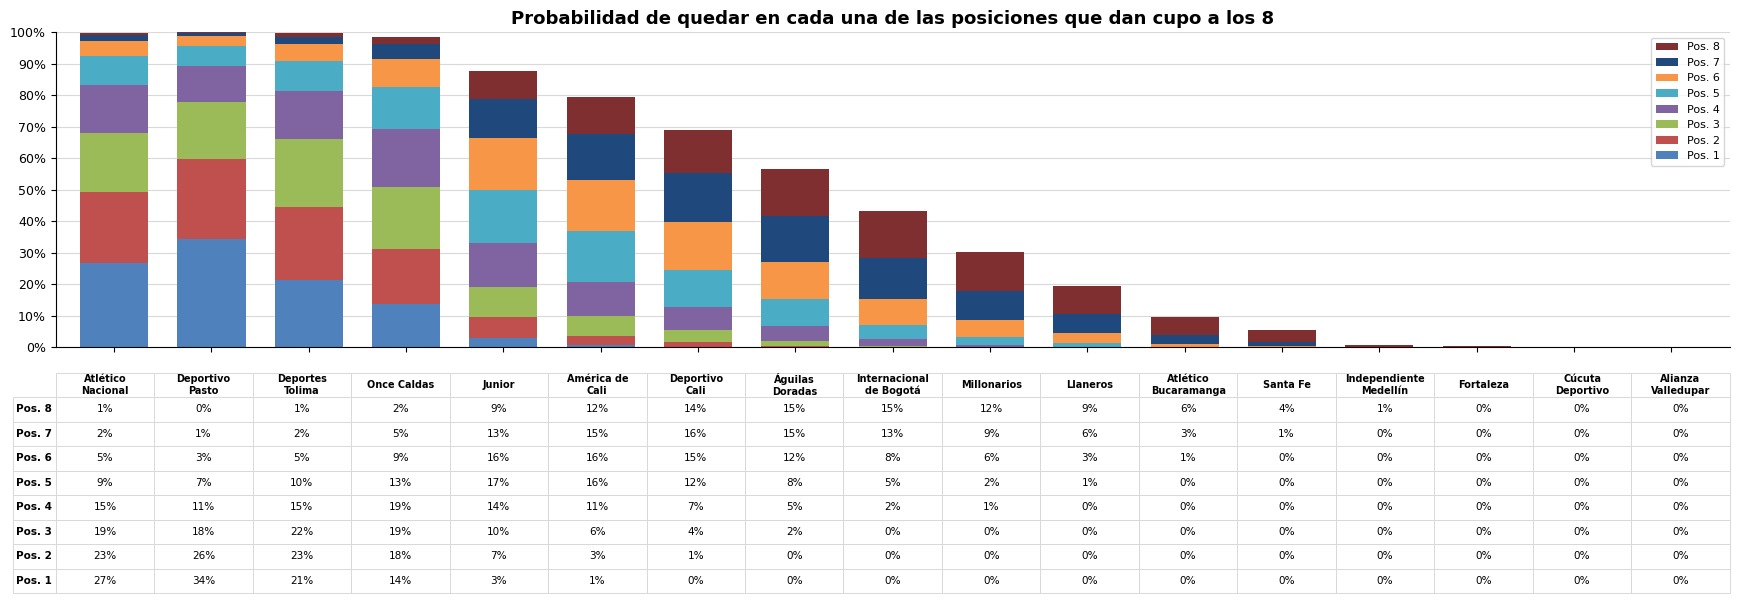

In [3]:
# Paleta similar al ejemplo (aprox. estilo Excel)
# Pos.1 -> azul, Pos.2 -> rojo, Pos.3 -> verde, Pos.4 -> morado,
# Pos.5 -> turquesa, Pos.6 -> naranja, Pos.7 -> azul oscuro, Pos.8 -> marron
colors = [
    '#4F81BD',  # Pos. 1
    '#C0504D',  # Pos. 2
    '#9BBB59',  # Pos. 3
    '#8064A2',  # Pos. 4
    '#4BACC6',  # Pos. 5
    '#F79646',  # Pos. 6
    '#1F497D',  # Pos. 7
    '#7F2F2F',  # Pos. 8
]

# Filtrar equipos con 0% en todas las posiciones 1..8
filtrar = resultados_top8.sum(axis=0) > 0
resultados_top8_f = resultados_top8.loc[:, filtrar].copy()
plot_df = resultados_top8_f.T

fig, ax = plt.subplots(figsize=(18, 9))

# Barra apilada (sin leyenda por defecto)
plot_df.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.7, legend=False)

# Estetica general
ax.set_title('Probabilidad de quedar en cada una de las posiciones que dan cupo a los 8', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 10))
ax.set_yticklabels([f'{i}%' for i in range(0, 101, 10)], fontsize=9)
ax.grid(axis='y', color='#D9D9D9', linewidth=0.8)
ax.set_axisbelow(True)

# Quitar borde superior y derecho para parecerse al estilo del ejemplo
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ocultar etiquetas del eje X (se muestran en la tabla)
ax.tick_params(axis='x', labelbottom=False)

# Leyenda en la parte superior derecha (sin titulo)
legend_handles = [Patch(facecolor=c, edgecolor='none', label=f'Pos. {i}')
                  for i, c in zip(range(1, 9), colors)]
legend = ax.legend(legend_handles[::-1], [f'Pos. {i}' for i in range(8, 0, -1)],
                   loc='upper right', frameon=True, fontsize=8)


# Tabla con porcentajes (0 decimales) y signo %
# Filas: posiciones (8..1), Columnas: equipos
raw_df = resultados_top8_f.copy().round(0).astype(int)
table_df = raw_df.sort_index(ascending=False)

# Labels de columnas con salto de linea sin cortar palabras
col_labels = []
for name in table_df.columns.tolist():
    if len(name) > 10:
        col_labels.append(textwrap.fill(name, width=12, break_long_words=False, break_on_hyphens=False))
    else:
        col_labels.append(name)

# Convertir a strings con %
cell_text = table_df.applymap(lambda v: f'{v}%').values

# Construir tabla debajo del grafico usando el mismo ancho del eje para alinear columnas con barras
# bbox: [left, bottom, width, height] en coordenadas del eje

table = ax.table(
    cellText=cell_text,
    rowLabels=[f'Pos. {i}' for i in table_df.index],
    colLabels=col_labels,
    cellLoc='center',
    rowLoc='center',
    bbox=[0.0, -0.78, 1.0, 0.7]
)

# Ajustes visuales de la tabla
table.auto_set_font_size(False)
table.set_fontsize(7.5)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#D9D9D9')
    cell.set_linewidth(0.7)
    if row == 0 or col == -1:
        cell.get_text().set_weight('bold')
    if row == 0:
        cell.get_text().set_fontsize(7)

# Espacio para la tabla
plt.subplots_adjust(left=0.06, right=0.99, top=0.9, bottom=0.55)

# Guardar imagen
plt.savefig('Resultado.png', dpi=150, bbox_inches='tight')

plt.show()
